# Plot feature selection results

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

## Load previously saved results

In [2]:
results = dict()
results['disability'] = \
    pd.read_csv('./output/feature_selection_disability_results.csv', index_col=0)
results['disability_no_treatment'] = \
    pd.read_csv('./output/feature_selection_disability_no_treatment_results.csv', index_col=0)
results['disability_less_3'] = \
    pd.read_csv('./output/feature_selection_disability_less_3_results.csv', index_col=0)
results['disability_less_6'] = \
    pd.read_csv('./output/feature_selection_disability_less_6_results.csv', index_col=0)
results['disability_less_3_no_treatment'] = \
    pd.read_csv('./output/feature_selection_disability_less_3_no_treatment_results.csv', index_col=0)
results['disability_less_6_no_treatment'] = \
    pd.read_csv('./output/feature_selection_disability_less_6_no_treatment_results.csv', index_col=0)
results['los'] = \
    pd.read_csv('./output/feature_selection_los_results.csv', index_col=0)
results['los_no_treatment'] = \
    pd.read_csv('./output/feature_selection_los_no_treatment_results.csv', index_col=0)
results['thrombolysis'] = \
    pd.read_csv('./output/feature_selection_thrombolysis_results.csv', index_col=0)
results['thrombolysis_induced_haemorrhage'] = \
    pd.read_csv('./output/feature_selection_thrombolysis_induced_haemorrhage_results.csv', index_col=0)
results['thrombectomy'] = \
    pd.read_csv('./output/feature_selection_thrombectomy_results.csv', index_col=0)

## Create dictionary for chart titles

In [3]:
titles = {
    'disability': 'Disability on discharge',
    'disability_no_treatment': 'Disability on discharge\n(untreated patients)',
    'disability_less_3': 'Disability on discharge mRS 0-2',
    'disability_less_3_no_treatment': 'Disability on discharge mRS 0-2\n(untreated patients)',
    'disability_less_6': 'Survival',
    'disability_less_6_no_treatment': 'Survival\n(untreated patients)',
    'los': 'Length of stay',
    'los_no_treatment': 'Length of stay\n(untreated patients)',
    'thrombolysis': 'Use of thrombolysis',
    'thrombectomy': 'Use of thrombectomy',
    'thrombolysis_induced_haemorrhage': 'Thrombolysis-induced haemorrhage'
}


## Plot feature selection

In [4]:
def plot_results(results_list, save_name):
    # Calculate the number of rows and columns needed for the subplots
    num_results = len(results_list)
    num_cols = 2
    num_rows = (num_results + num_cols - 1) // num_cols  # This ensures that we round up to the nearest whole number of rows

    # Create a 4 x 2 grid of subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(14, 6 * num_rows))

    # Hide any unused subplots
    for ax in axs.flat[len(results_list):]:
        ax.axis('off')

    # Loop through each result. Plot feature as X and score as Y. Use the title of the plot as the key of the result.
    for i, result_name in enumerate(results_list):
        result = results[result_name]
        # Try score as "Mean AUC", otherwise use "Mean r2"
        if 'Mean AUC' in result.columns:
            score_col = 'Mean AUC'
        else:
            score_col = 'Mean r2'
        ax = axs[i // 2, i % 2]
        ax.plot(result['Chosen Feature'], result[score_col], marker='o')
        ax.set_title(titles.get(result_name, result_name))
        #ax.set_xlabel('Feature')
        # Use "AUC" or "R-Squared" as the Y label depending on the score column
        if score_col == 'Mean AUC':
            ax.set_ylabel('AUC')
        else:
            ax.set_ylabel('R-Squared')
        ax.set_xticks(range(len(result['Chosen Feature'])))
        ax.set_xticklabels(result['Chosen Feature'], rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(f'./output/{save_name}.png', dpi=300)
    plt.show()

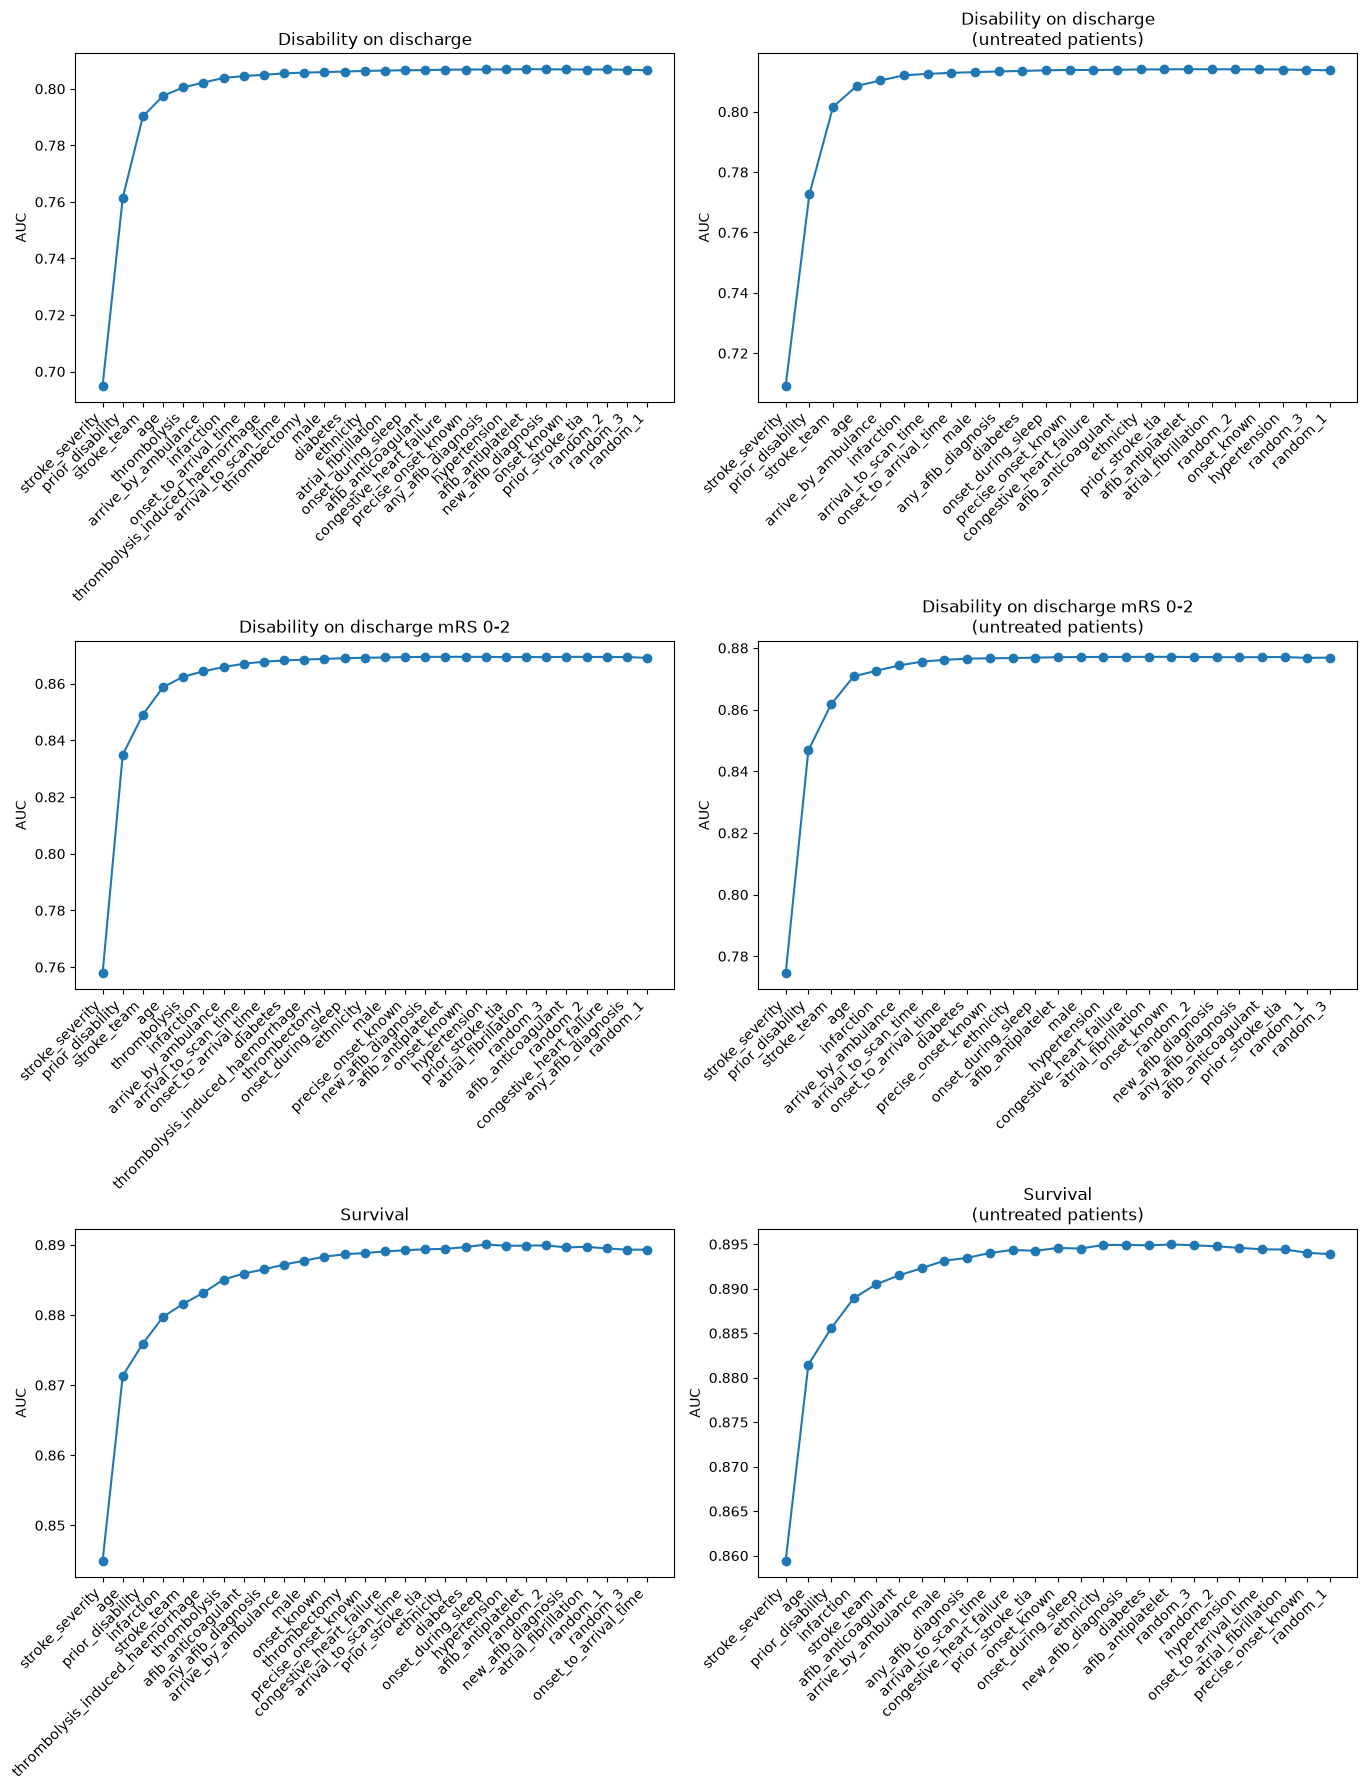

In [5]:
results_list = [
    'disability',
    'disability_no_treatment',
    'disability_less_3',
    'disability_less_3_no_treatment',
    'disability_less_6',
    'disability_less_6_no_treatment'
]

plot_results(results_list, 'feature_selection_1')

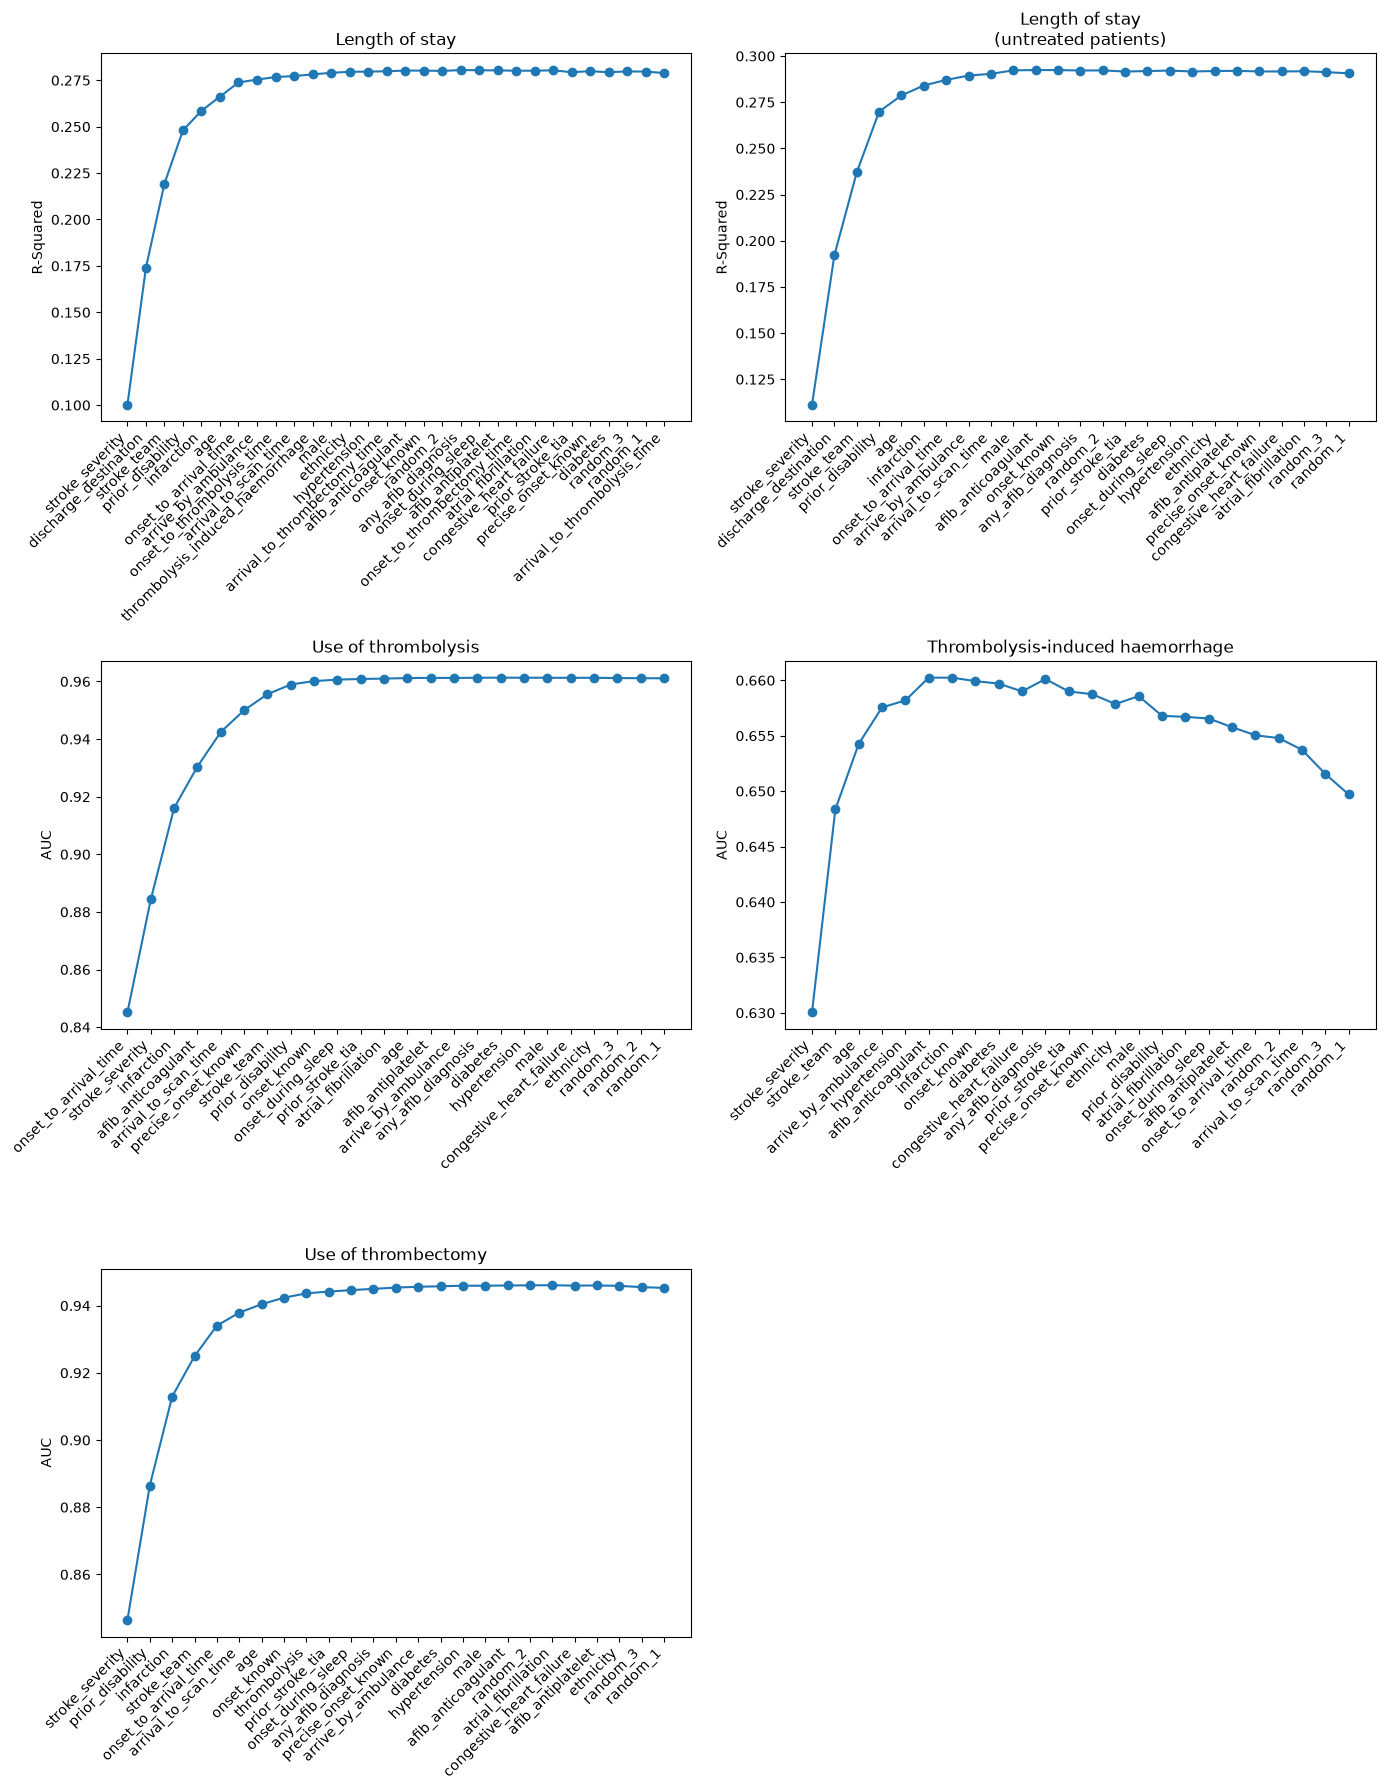

In [6]:
results_list = [
    'los',
    'los_no_treatment',
    'thrombolysis',
    'thrombolysis_induced_haemorrhage',
    'thrombectomy',
]

plot_results(results_list, 'feature_selection_2')